# RQ4 Ablation: Influence of the ChangeApprover
**Improvement in Plausible Fixes**

In [72]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

In [73]:
# --- Data ---
labels = [
    "No Change\nApprover",
    "1. Step\n(Build)",
    "1. & 2. Step\n(Build & Analysis)",
    "Full Change\nApprover",
]
values = [75.1, 86.1, 96.1, 96.8]
improvements = [None, "+11%", "+10%", "+0.7%"]
total_improvement = "+21.7%"
# Colors (left = darkest, right = moderately bright blue)
bar_colors = [
"#1B3A52",   # darkest blue
"#2569AE",   # mid-dark blue
"#2984C7",   # moderate blue (less light than before)
"#4CB4E7"    # light but less aggressive blue
]
improvement_color = "#1DB954"  # vivid green
arrow_color = "#29A85A"     # slightly muted green for connectors

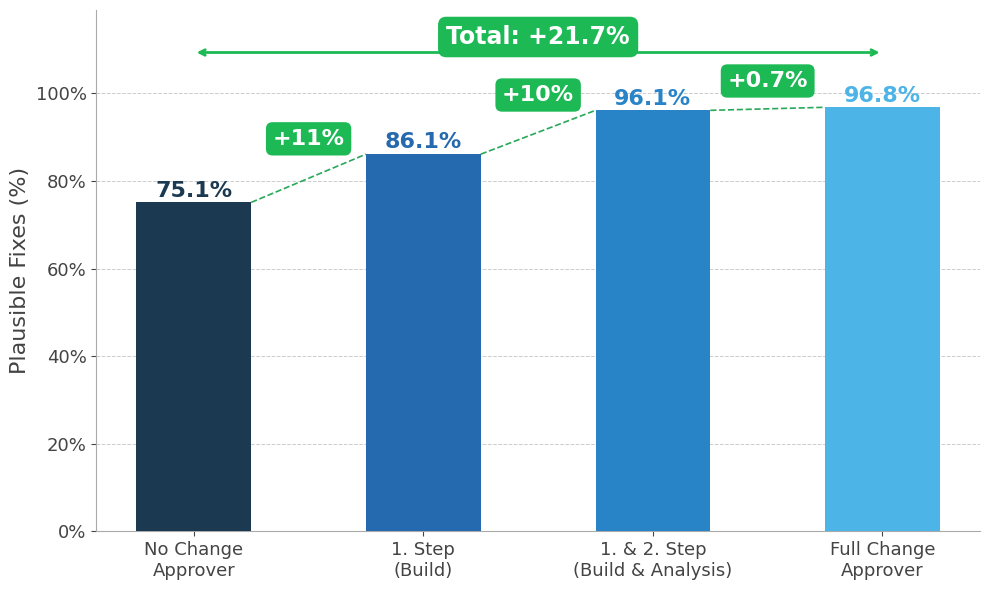

Figure saved as change_approver_ablation.pdf


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#F0EDE8")   # light beige background like the slide
ax.set_facecolor("#F0EDE8")

x = np.arange(len(labels))
bar_width = 0.5

bars = ax.bar(x, values, width=bar_width, color=bar_colors,  # changed to color=bar_colors
              zorder=3, linewidth=0)

# --- Value labels on top of each bar ---
for i, (bar, val) in enumerate(zip(bars, values)):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.4,
        f"{val}%",
        ha="center", va="bottom",
        fontsize=16, fontweight="bold", color=bar_colors[i]  # Increased fontsize
    )

# --- Improvement annotations between bars ---
for i in range(1, len(values)):
    x_prev = x[i - 1] + bar_width / 2
    x_curr = x[i] - bar_width / 2
    y_prev = values[i - 1]
    y_curr = values[i]
    mid_x = (x[i - 1] + x[i]) / 2
    # Move the improvement pill label a lot higher for the rightmost (+0.7%)
    if i == len(values) - 1:
        label_y = max(y_prev, y_curr) + 6  # much higher
    else:
        label_y = max(y_prev, y_curr) + 3.5

    # Dashed connector line between bar tops
    ax.plot(
        [x[i - 1] + bar_width / 2, x[i] - bar_width / 2],
        [y_prev, y_curr],
        color=arrow_color, linewidth=1.2,
        linestyle="--", zorder=4
    )

    # Green pill background for improvement label
    ax.text(
        mid_x, label_y,
        improvements[i],
        ha="center", va="center",
        fontsize=16, fontweight="bold", color="white",  # Increased fontsize
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor=improvement_color,
            edgecolor="none"
        ),
        zorder=5
    )

# --- Total improvement bracket ---
bracket_y = max(values) + 13
x_start = x[0]
x_end = x[-1]

ax.annotate(
    "",
    xy=(x_end, bracket_y - 0.5), xytext=(x_start, bracket_y - 0.5),
    arrowprops=dict(
        arrowstyle="<->",
        color=improvement_color,
        lw=2
    ),
    zorder=5
)
ax.text(
    (x_start + x_end) / 2, bracket_y + 0.3,
    f"Total: {total_improvement}",
    ha="center", va="bottom",
    fontsize=17, fontweight="bold", color="white",  # Increased fontsize
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor=improvement_color,
        edgecolor="none"
    ),
    zorder=6
)

# --- Axes formatting ---
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=15.5)  # Increased fontsize
ax.set_ylabel("Plausible Fixes (%)", fontsize=16)  # Increased fontsize
ax.set_ylim(0, 115)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))


ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#aaa")
ax.tick_params(colors="#444", labelsize=13)  # Increased tick fontsize
ax.yaxis.label.set_color("#444")
ax.grid(axis="y", color="#ccc", linewidth=0.7, linestyle="--", zorder=0)

plt.tight_layout()
# Make figure and axes backgrounds transparent for PNG export
fig = plt.gcf()
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)
plt.savefig("../evaluation_results/plots/change_approver_ablation.pdf", bbox_inches="tight", dpi=150)
plt.savefig("../evaluation_results/plots/change_approver_ablation.png", bbox_inches="tight", dpi=300, transparent=True)
plt.show()
print("Figure saved as change_approver_ablation.pdf")